Vértices: 93 | Arestas: 2667


--- COMPONENTES CONEXAS ---

[Componentes Conexas]
Componentes Fracamente Conexas: 1
Componentes Fortemente Conexas: 65
A maior componente forte tem 29 vértices (31.2% da rede).


--- ANALISE DE CICLOS ---

[Análise de Ciclos]
A rede possui ciclos.
Auto-loops: 0
Ciclos de tamanho 3 'perfeitos': 0


--- ILUSTRAÇÃO DA REDE ---


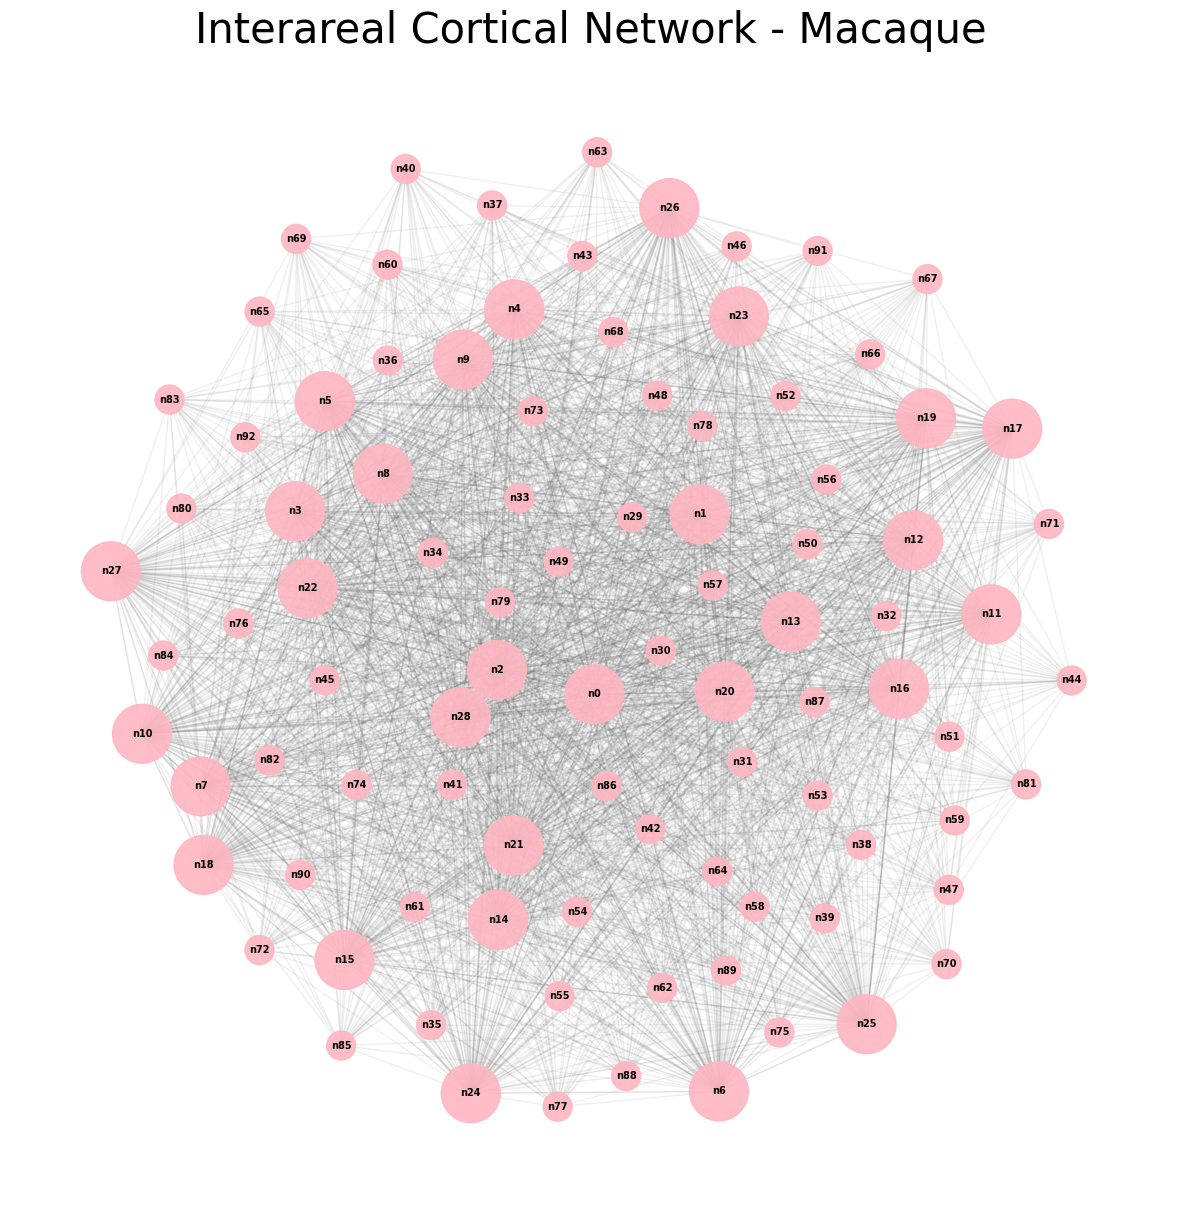



--- CENTRALIDADE ---

 Top 5 Degree Centrality:
  n0: 1.3043
  n1: 1.3043
  n2: 1.3043
  n3: 1.3043
  n4: 1.3043

 Top 5 Betweenness Centrality:
  n0: 0.0000
  n1: 0.0000
  n2: 0.0000
  n3: 0.0000
  n4: 0.0000

 Top 5 Closeness Centrality:
  n0: 1.0000
  n1: 1.0000
  n2: 1.0000
  n3: 1.0000
  n4: 1.0000


--- DISTÂNCIAS ---


A rede NÃO é totalmente conexa. Analisando a maior componente.
Tamanho da maior componente: 29 vértices (de 93 totais)

 Raio: 1
 Diâmetro: 2
 Centro (Vértices centrais): ['n10', 'n4', 'n25', 'n22', 'n9', 'n8', 'n17', 'n12', 'n19', 'n6', 'n18', 'n21', 'n2', 'n13', 'n3', 'n20', 'n26', 'n11', 'n15', 'n5', 'n23', 'n28', 'n24', 'n16', 'n27', 'n1', 'n0', 'n14']
 Periferia: ['n7']

 Top 5 Menor Excentricidade:
  n10: 1
  n4: 1
  n25: 1
  n22: 1
  n9: 1


--- GRAU DOS VÉRTICES ---

 Grau de Entrada:
Mín/Máx: 0 - 92
Média: 28.68
Frequência: [(0, 64), (92, 28), (91, 1)]

 Grau de Saída:
Mín/Máx: 27 - 29
Média: 28.68
Frequência: [(29, 64), (28, 28), (27, 1)]


--- AGM, CL

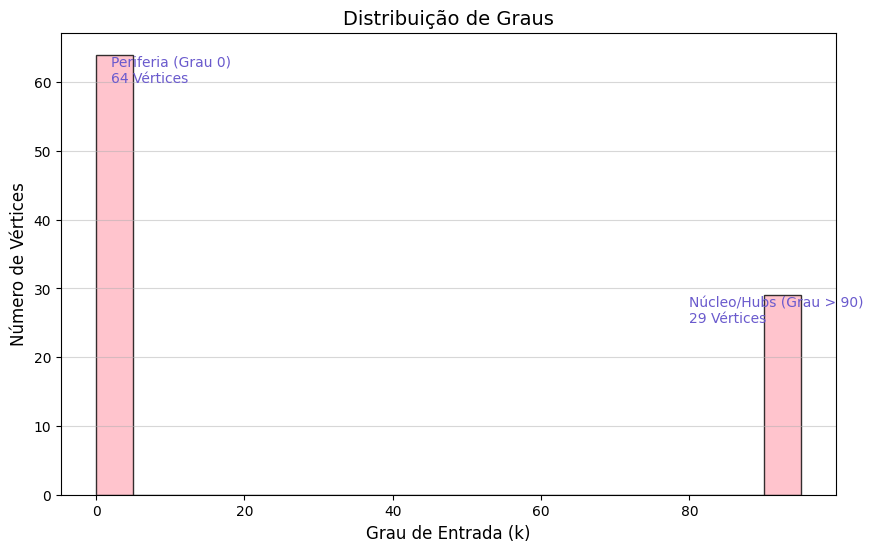

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from networkx.algorithms.community import greedy_modularity_communities
import numpy as np


filename = "rhesus_interareal.cortical.network_2.graphml"

# le o arquivo
G = nx.read_graphml(filename)

mapping = nx.get_node_attributes(G, 'v_name')
if mapping:
  G = nx.relabel_nodes(G, mapping)

# analise esttrutural e de componentes conexas
print(f"Vértices: {G.number_of_nodes()} | Arestas: {G.number_of_edges()}")

print(f"\n\n--- COMPONENTES CONEXAS ---")

n_fraca = nx.number_weakly_connected_components(G)
print(f"\n[Componentes Conexas]")
print(f"Componentes Fracamente Conexas: {n_fraca}")

n_forte = nx.number_strongly_connected_components(G)
print(f"Componentes Fortemente Conexas: {n_forte}")

# pega a maior componente para cálculos de distância
maior_componente = max(nx.strongly_connected_components(G), key=len)
LCC = G.subgraph(maior_componente)
print(f"A maior componente forte tem {LCC.number_of_nodes()} vértices "
    f"({len(maior_componente)/G.number_of_nodes():.1%} da rede).")

# analise de ciclos
print(f"\n\n--- ANALISE DE CICLOS ---")

print(f"\n[Análise de Ciclos]")
# verificar se é um DAG
if nx.is_directed_acyclic_graph(G):
  print("A rede é acíclica.")
else:
  print("A rede possui ciclos.")

  # conta os ciclos de um vértice nele mesmmo
  auto_loop = list(nx.nodes_with_selfloops(G))
  print(f"Auto-loops: {len(auto_loop)}")
  try:
      # o código '030C' representa um ciclo do tipo A->B->C->A
      ciclos = nx.triadic_census(G)
      print(f"Ciclos de tamanho 3 'perfeitos': {ciclos.get('030C', 0)}")
  except Exception as e_triad:
        print(f"Não foi possível calcular: {e_triad}")

# gera imagem da rede

print(f"\n\n--- ILUSTRAÇÃO DA REDE ---")

plt.figure(figsize=(15, 15))

pos = nx.spring_layout(G, k=0.6, iterations=50, seed=42)

# desenha o tamanho dos vertices com base no seu grau
graus = [G.degree(n) for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_size=[v * 15 for v in graus], node_color='lightpink', alpha=0.9)

nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='dimgray', arrows=False)

nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')

plt.title("Interareal Cortical Network - Macaque", fontsize=30)
plt.axis('off')

plt.savefig("visualizacao_rede.png", dpi=300, bbox_inches='tight')
plt.show()


# funcao auxiliar para imprimir o top 5 de vertices
def print_top5(metric_dict, nome_metrica):
    print(f"\n Top 5 {nome_metrica}:")
    top = sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:5]
    for area, valor in top:
        print(f"  {area}: {valor:.4f}")

print(f"\n\n--- CENTRALIDADE ---")

# degree
print_top5(nx.degree_centrality(G), "Degree Centrality")

# betweenness
print_top5(nx.betweenness_centrality(G), "Betweenness Centrality")

# closeness
close = nx.closeness_centrality(G)
print_top5(close, "Closeness Centrality")

print(f"\n\n--- DISTÂNCIAS ---")

print(f"\n")
if nx.is_strongly_connected(G):
    H = G
    print("A rede é fortemente conexa. Analisando todo o grafo.")
else:
    print("A rede NÃO é totalmente conexa. Analisando a maior componente.")
    largest_cc = max(nx.strongly_connected_components(G), key=len)
    H = G.subgraph(largest_cc)
    print(f"Tamanho da maior componente: {len(H)} vértices (de {len(G)} totais)")

# excentricidade
excentrecidade = nx.eccentricity(H)

# raio
raio = nx.radius(H)
print(f"\n Raio: {raio}")

# diâmetro
diametro = nx.diameter(H)
print(f" Diâmetro: {diametro}")

# centro
centro = nx.center(H)
print(f" Centro (Vértices centrais): {centro}")

# periferia
periferia = nx.periphery(H)
print(f" Periferia: {periferia}")

# top 5 excentricidade
print(f"\n Top 5 Menor Excentricidade:")
# ordenamos crescente porque excentricidade baixa é melhor/ o vertice esta mais central
top_exc = sorted(excentrecidade.items(), key=lambda x: x[1])[:5]
for area, valor in top_exc:
    print(f"  {area}: {valor}")


print(f"\n\n--- GRAU DOS VÉRTICES ---")
grau_entrada = [d for n, d in G.in_degree()]
grau_saida = [d for n, d in G.out_degree()]

def resumir(lista, nome):
    print(f"\n {nome}:")
    print(f"Mín/Máx: {min(lista)} - {max(lista)}")
    print(f"Média: {sum(lista)/len(lista):.2f}")
    print(f"Frequência: {Counter(lista).most_common(3)}")

resumir(grau_entrada, "Grau de Entrada")
resumir(grau_saida, "Grau de Saída")

# versão não direcionada para algoritmo de clique
G_nao_direcionado = G.to_undirected()

print(f"\n\n--- AGM, CLUSTER E CLIQUE ---")

agm_rede = nx.maximum_spanning_tree(G_nao_direcionado, weight='weight')

print(f"\nÁrvore Geradora Máxima:")
print(f"A AGM conecta {agm_rede.number_of_nodes()} áreas com apenas {agm_rede.number_of_edges()} arestas.")
peso_total = sum(d['weight'] for u, v, d in agm_rede.edges(data=True))
print(f"Peso total da AGM: {peso_total:.2f}")

print(f"\nClusters:")

coeficiente_medio = nx.average_clustering(G)
print(f"Coeficiente de Agrupamento Médio: {coeficiente_medio:.4f}")

print(f"\nCliques:")

cliques = list(nx.find_cliques(G_nao_direcionado))

maior_clique = max(cliques, key=len)

print(f"Total de cliques encontrados: {len(cliques)}")
print(f"Tamanho do Maior Clique: {len(maior_clique)}")
print(f"Vértices que formam o Maior Clique:")
print(f"{maior_clique}")

print("\n\n--- CICLOS EULERIANOS E HAMILTONIANO ---")

is_eulerian = nx.is_eulerian(G)
has_eulerian_path = nx.has_eulerian_path(G)

print(f"\nCiclo Euleriano:")
print(f"Possui Ciclo Euleriano fechado? {'SIM' if is_eulerian else 'NÃO'}")
print(f"Possui Caminho Euleriano aberto? {'SIM' if has_eulerian_path else 'NÃO'}")

def check_hamiltonian_tsp(graph):
    try:
        # tenta encontrar o menor ciclo que visita todos os nós
        cycle = nx.approximation.traveling_salesman_problem(graph, cycle=True)
        num_vertices = graph.number_of_nodes()
        cycle_len = len(cycle) - 1

        if cycle_len == num_vertices:
            return True, f"Encontrado ciclo com {cycle_len} passos."
        else:
            return False, f"O melhor caminho precisou de {cycle_len} passos para visitar {num_vertices} vértices."

    except Exception as e:
        return False, f"Erro no cálculo: {e}"

is_hamiltonian, message = check_hamiltonian_tsp(G_nao_direcionado)
print(f"É Hamiltoniano? {is_hamiltonian}")
print(f"Detalhe: {message}")

# gera um grafico para ilustrar o grau dos vertices perifericos comparados com o grau dos vertices centrais(hubs)

graus = [d for n, d in G.in_degree()]

plt.figure(figsize=(10, 6))

plt.hist(graus, bins=range(0, 100, 5), color='lightpink', edgecolor='black', alpha=0.8)

plt.title('Distribuição de Graus', fontsize=14)
plt.xlabel('Grau de Entrada (k)', fontsize=12)
plt.ylabel('Número de Vértices', fontsize=12)
plt.grid(axis='y', alpha=0.5)

plt.text(2, 60, 'Periferia (Grau 0)\n64 Vértices', fontsize=10, color='slateblue')
plt.text(80, 25, 'Núcleo/Hubs (Grau > 90)\n29 Vértices', fontsize=10, color='slateblue')

plt.savefig('grafico_grau.png')
plt.show()

